In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Sales data
salesData = {
    "SalesYear": [2018, 2019, 2020, 2021, 2022],
    "Revenue": [150, 200, 250, 300, 350],
    "Profit": [50, 80, 120, 150, 200],
    "Expenses": [100, 120, 130, 150, 170],
}

In [3]:
# Load data into a DataFrame
df = pd.DataFrame(salesData)

# Display the DataFrame
print(df)

   SalesYear  Revenue  Profit  Expenses
0       2018      150      50       100
1       2019      200      80       120
2       2020      250     120       130
3       2021      300     150       150
4       2022      350     200       170


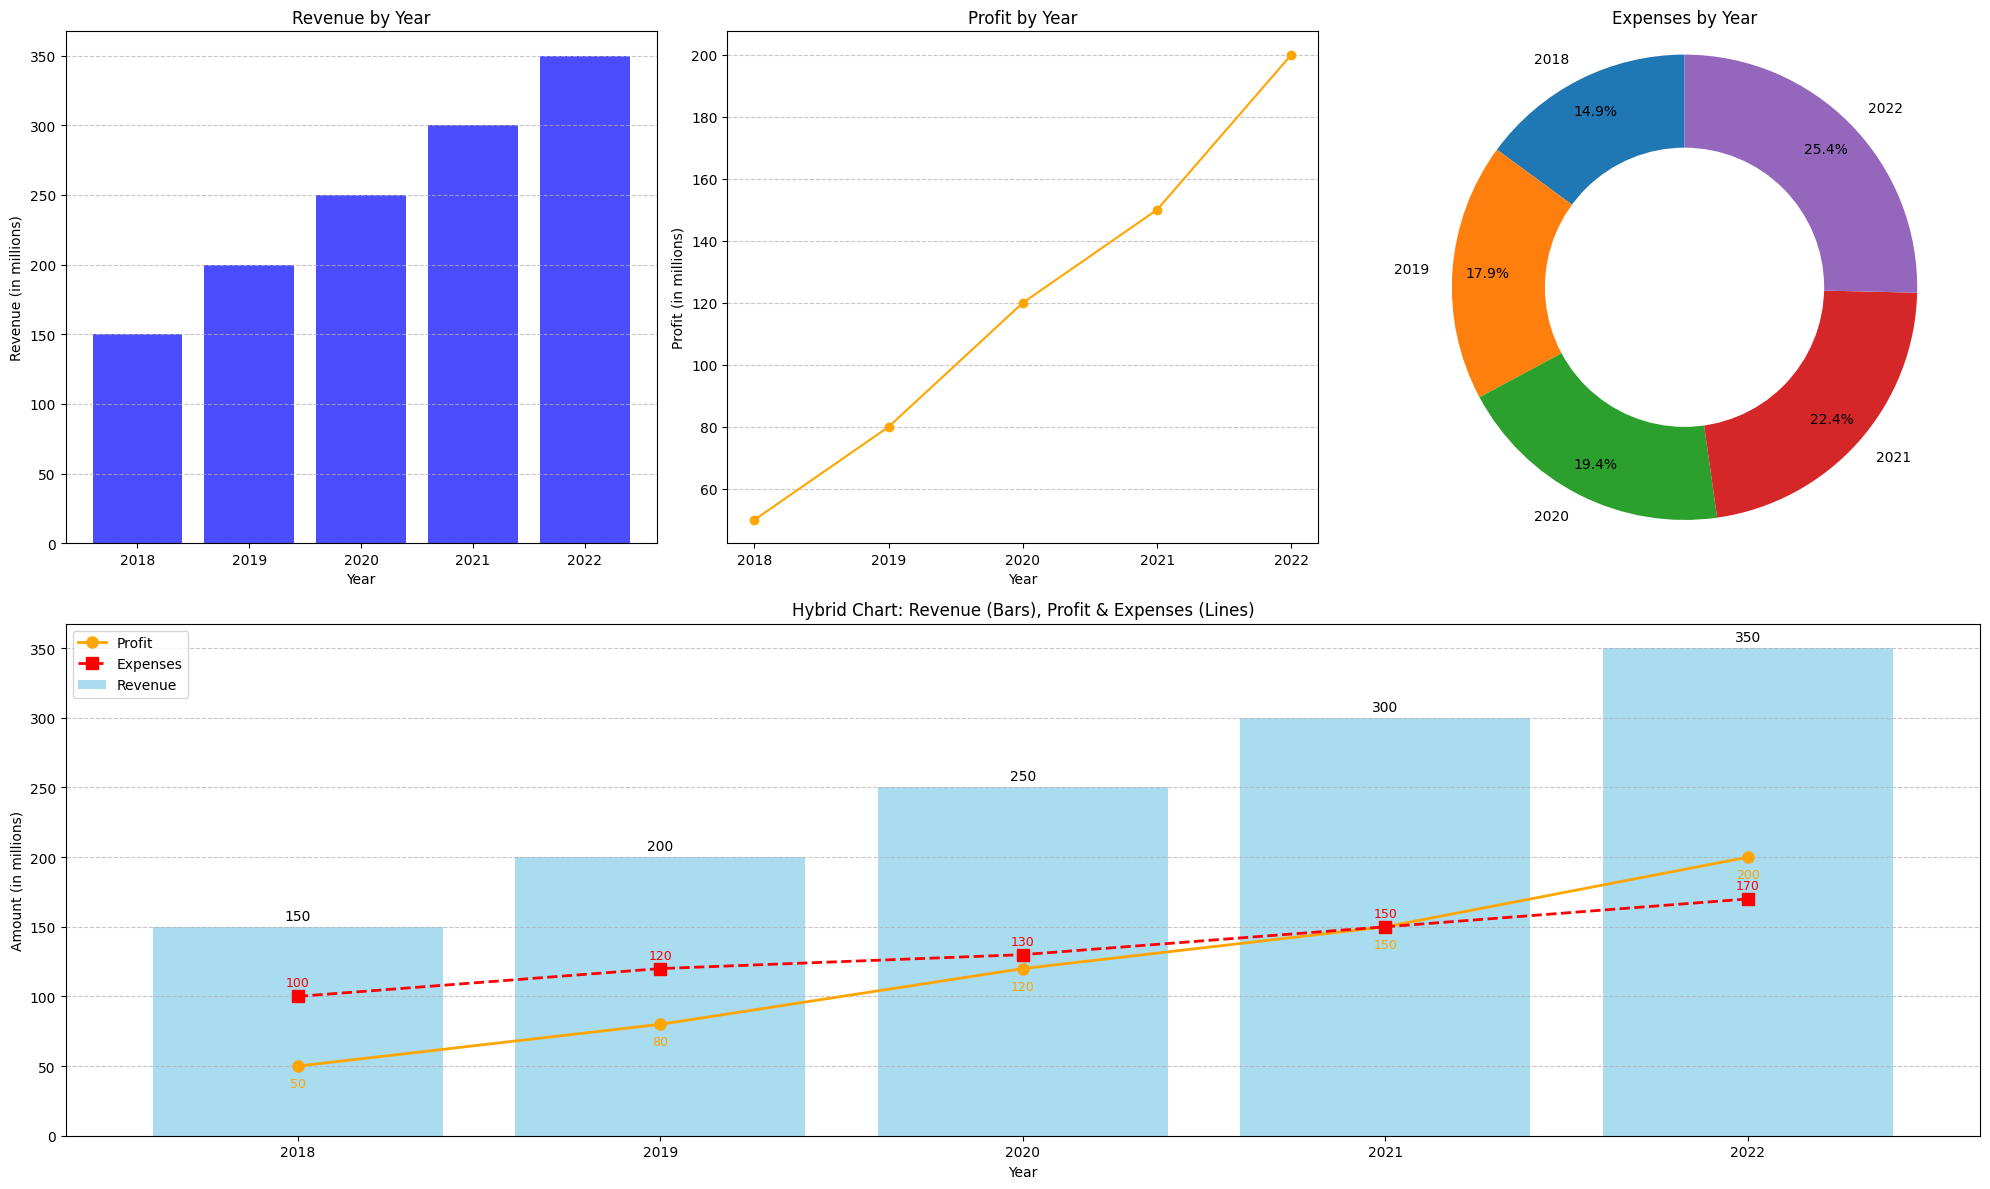

In [5]:
# Create subplots with 2 rows: first row has 3 charts, second row has a hybrid chart combining revenue, profit, and expenses
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

# First row subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Bar chart for Revenue
ax1.bar(df["SalesYear"], df["Revenue"], color="blue", alpha=0.7)
ax1.set_title("Revenue by Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (in millions)")
ax1.set_xticks(df["SalesYear"])
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Line chart for Profit
ax2.plot(df["SalesYear"], df["Profit"], marker="o", color="orange", linestyle="-")
ax2.set_title("Profit by Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Profit (in millions)")
ax2.set_xticks(df["SalesYear"])
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# Donut chart for Expenses
wedges, texts, autotexts = ax3.pie(
    df["Expenses"],
    labels=df["SalesYear"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85,
)
# Draw a white circle in the center to make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax3.add_artist(centre_circle)
ax3.set_title("Expenses by Year")
ax3.axis('equal')

# Second row: Hybrid chart combining revenue (bars), profit and expenses (lines)
ax4 = fig.add_subplot(gs[1, :])

# Bar chart for Revenue
bars = ax4.bar(df["SalesYear"], df["Revenue"], color="skyblue", alpha=0.7, label="Revenue")
ax4.bar_label(bars, padding=3, fontsize=10)

# Line chart for Profit
ax4.plot(df["SalesYear"], df["Profit"], marker="o", markersize=8, color="orange", linestyle="-", linewidth=2, label="Profit")

# Line chart for Expenses
ax4.plot(df["SalesYear"], df["Expenses"], marker="s", markersize=8, color="red", linestyle="--", linewidth=2, label="Expenses")

# Add data labels for Profit
for i, (x, y) in enumerate(zip(df["SalesYear"], df["Profit"])):
    ax4.text(x, y - 8, f'{y}', ha='center', va='top', fontsize=9, color='orange')

# Add data labels for Expenses
for i, (x, y) in enumerate(zip(df["SalesYear"], df["Expenses"])):
    ax4.text(x, y + 5, f'{y}', ha='center', va='bottom', fontsize=9, color='red')

ax4.set_title("Hybrid Chart: Revenue (Bars), Profit & Expenses (Lines)")
ax4.set_xlabel("Year")
ax4.set_ylabel("Amount (in millions)")
ax4.set_xticks(df["SalesYear"])
ax4.grid(axis="y", linestyle="--", alpha=0.7)
ax4.legend()

plt.tight_layout()
plt.show()